In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
import os, random
from sklearn.preprocessing import StandardScaler
import joblib



# Print and store device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
MASS = 135

# Define important parameters

In [3]:
# Number of class in invariant mass used by the adversary
Num_classes = 10
# Hyper-parameter for adversarial training of the classifier
lambda_ = 10.0

run = 42

# This ensures repeatability
def seed_everything(seed: int = 0):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(int(run))

# Load and setup the data

In [4]:
# Read tritrig, wab, phiKK, and data files
df_bigpreselectblind = pd.read_pickle('bigpreselectblind.pk')
df_bigpreselectblind['PhiKK'] = 0.0 # Add label
df_simp150pres = pd.read_pickle('simp'+str(MASS)+'pres.pk')
df_simp150pres['PhiKK'] = 1.0 # Add label

# Data-like MC files (hit-smear-kill tridents): used as background alongside real data.
df_wab_dm    = pd.read_pickle('wab_HPS_Run2021Pass1_v9_14272_hitSmearKill_2000files.pk')
df_tritrig_dm = pd.read_pickle('tritrig_HPS_Run2021Pass1_v9_14272_hitSmearKill_1000files.pk')
df_wab_dm['PhiKK']     = 0.0  # background label – same as real data
df_tritrig_dm['PhiKK'] = 0.0

# Combine data-like MC into one frame for convenience
df_mc_bkg = pd.concat([df_wab_dm, df_tritrig_dm], ignore_index=True, sort=False)

print('data bkg:        ', len(df_bigpreselectblind))
print('data-like MC bkg:', len(df_mc_bkg))
print('simp:            ', len(df_simp150pres))


data bkg:         4655616
data-like MC bkg: 258843
simp:             348767


In [5]:
# Split real data background and data-like MC background
df_bigpreselectblind_train, df_bigpreselectblind_test = train_test_split(df_bigpreselectblind, test_size=0.20, random_state=42)
df_mc_bkg_train,            df_mc_bkg_test            = train_test_split(df_mc_bkg,            test_size=0.5,  random_state=42)
df_simp150pres_train,       df_simp150pres_test       = train_test_split(df_simp150pres,       test_size=0.5,  random_state=42)

# ── Build a 50/50 data/MC background by downsampling data to match MC count ──
# We want the background class to be half real data, half data-like MC.
# Since data >> MC, we subsample the data training pool to len(df_mc_bkg_train),
# then assign per-sample weights so each source contributes equally in expectation.
#
# Statistical reweighting:
#   real data events : weight = 1.0
#   MC bkg events    : weight = N_data_train / N_mc_train  (upweight to compensate for fewer MC)
#
# This means the classifier and mass-adversary losses treat MC events as more
# informative proportionally to how many fewer of them there are.

N_mc_train  = len(df_mc_bkg_train)
N_data_train = len(df_bigpreselectblind_train)
mc_weight   = N_data_train / N_mc_train   # upweight factor for MC bkg events

# Subsample data background to match MC size for a balanced 50/50 mix
df_data_bkg_train_sub = df_bigpreselectblind_train.sample(n=N_mc_train, random_state=42)

# Attach sample weights as a column before concatenation
df_data_bkg_train_sub = df_data_bkg_train_sub.copy()
df_mc_bkg_train       = df_mc_bkg_train.copy()
df_simp150pres_train  = df_simp150pres_train.copy()

df_data_bkg_train_sub['sample_weight'] = 1.0
df_mc_bkg_train      ['sample_weight'] = 1.0 #mc_weight
df_simp150pres_train ['sample_weight'] = 1.0   # signal weight; masked out in adv loss anyway

# Do the same split arithmetic for validation — use the same weight ratio
N_mc_val   = len(df_mc_bkg_test)   # we'll take a val slice below

# Combine and shuffle all training data
df_train = pd.concat([df_data_bkg_train_sub, df_mc_bkg_train, df_simp150pres_train],
                      ignore_index=True, sort=False)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

one_hot_edges = mytools.get_one_hot_edges(df_bigpreselectblind.InvM, n_bins=Num_classes)

# Split into train / val
df_train, df_val = train_test_split(df_train, test_size=0.33, random_state=42)

# Test set: keep real data background only for the signal/background evaluation
# (consistent with the original — MC bkg test set used only for DM diagnostic below)
df_test = pd.concat([df_bigpreselectblind_test, df_simp150pres_test],
                     ignore_index=True, sort=False)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)

print('Train size:', len(df_train), '  Val size:', len(df_val), '  Test size:', len(df_test))
print(f'MC upweight factor: {mc_weight:.3f}')


Train size: 290260   Val size: 142965   Test size: 1105508
MC upweight factor: 28.778


In [6]:
# Make X and y for training and validation sets
# the adverserial network has its own labels
X_train = df_train.drop(columns=['InvM','PhiKK','sample_weight'])
y_train = df_train['PhiKK']
w_train = df_train['sample_weight']   # per-sample weights for classifier + adv losses
y_adv_train = mytools.get_adv_labels(df_train.InvM, one_hot_edges)
X_val = df_val.drop(columns=['InvM','PhiKK','sample_weight'])
y_val = df_val['PhiKK']
w_val = df_val['sample_weight']
y_adv_val = mytools.get_adv_labels(df_val.InvM, one_hot_edges)

X_test = df_test.drop(columns=['InvM','PhiKK'])
y_test = df_test['PhiKK']
y_adv_test = mytools.get_adv_labels(df_test.InvM, one_hot_edges)

# ── Classifier mass window mask (±8 MeV around the signal mass) ──
# The classifier BCE loss is only computed for events within this window.
# This prevents the classifier learning to identify the invariant mass region
# rather than genuine signal kinematics. InvM is in GeV; MASS is in MeV.
mass_window_GeV = 0.008  # 8 MeV half-width
mass_centre_GeV = MASS / 1000.0

clas_mask_train = ((df_train.InvM >= mass_centre_GeV - mass_window_GeV) &
                   (df_train.InvM <= mass_centre_GeV + mass_window_GeV)).astype(np.float32).values
clas_mask_val   = ((df_val.InvM   >= mass_centre_GeV - mass_window_GeV) &
                   (df_val.InvM   <= mass_centre_GeV + mass_window_GeV)).astype(np.float32).values

print(f'Mass window: [{1000*(mass_centre_GeV-mass_window_GeV):.1f}, {1000*(mass_centre_GeV+mass_window_GeV):.1f}] MeV')
print(f'Train events in window: {clas_mask_train.sum():.0f} / {len(clas_mask_train)}')
print(f'Val   events in window: {clas_mask_val.sum():.0f} / {len(clas_mask_val)}')


Mass window: [127.0, 143.0] MeV
Train events in window: 101853 / 290260
Val   events in window: 50484 / 142965


In [ ]:
# Scall all input data
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index) # The scaler is fit to the the training data
X_val   = pd.DataFrame(scaler.transform(X_val),       columns=X_val.columns,   index=X_val.index) # The same scaler is applied to validation and testing data 
print(X_val)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

# Save the scaler so it can be applied consistently during inference
joblib.dump(scaler, "scaler_2021_v9_pass5_run"+str(run)+"_QualCuts_"+str(MASS)+"_v3.pkl")
print(f"Standardized {X_train.shape[1]} features using training-set statistics.")

        vertex_pos_x  vertex_pos_y  vertex_pos_z      psum  ele_track_n_hits  \
210656     -1.081425     -0.125660     -0.676496  2.164677          1.149200   
63563      -2.369778     -3.677484     -2.471887  0.822169          1.909755   
85146      -1.480228      0.969679     -0.820242  0.223556         -0.371911   
236316     -0.375483      0.582120     -0.646878 -0.953043          0.388644   
23281       0.009208      0.492353     -0.403969  0.341588          1.149200   
...              ...           ...           ...       ...               ...   
95198      -0.047412      0.810264      0.243941 -0.146096          1.149200   
395800     -1.165446      0.036441     -0.543806  0.856691          1.149200   
25539       1.348141      2.919255      3.020415  0.030513         -1.132467   
354133     -0.296668     -0.988661      0.023149  1.004303         -0.371911   
181402      0.259531     -0.456845      1.386583  0.802062          0.388644   

        ele_track_d0  ele_track_phi0  e

## Setup dataloaders

In [8]:
bsize = 2000

# Convert to tensor dataset and create dataloaders.
# clas_mask is carried in the dataset so the training loop can zero out
# classifier BCE loss for events outside the ±8 MeV mass window.
train_dataset = TensorDataset(
    torch.from_numpy(X_train.to_numpy().astype(np.float32)),
    torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1),
    torch.from_numpy(clas_mask_train).unsqueeze(1))
train_loader = DataLoader(train_dataset, batch_size=bsize, shuffle=True)

val_dataset = TensorDataset(
    torch.from_numpy(X_val.to_numpy().astype(np.float32)),
    torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1),
    torch.from_numpy(clas_mask_val).unsqueeze(1))
val_loader = DataLoader(val_dataset, batch_size=bsize, shuffle=False)

test_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy().astype(np.float32)))
test_loader = DataLoader(test_dataset, batch_size=bsize, shuffle=False)


C:\Users\Rory\AppData\Local\Temp\ipykernel_33224\359436505.py:9: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  torch.from_numpy(clas_mask_train).unsqueeze(1))


## Initialize model, objective function, and optimizer

In [9]:
clas = mytools.Classifier(in_features=X_train.shape[1]).to(device)
criterion_clas = nn.BCEWithLogitsLoss()
optimizer_clas = optim.Adam(clas.parameters(), lr=1e-2)
scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=1.0)


## Pre-train the classifier

In [10]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest validation loss is stored as final_classifier
# Only events within the ±8 MeV mass window contribute to the classifier BCE loss.
patience = 10

BCE_pretrain = nn.BCEWithLogitsLoss(reduction='none')

def train_clas_windowed(loader, model, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch, mask_batch in loader:
        X_batch, y_batch, mask_batch = X_batch.to(device), y_batch.to(device), mask_batch.to(device)
        optimizer.zero_grad()
        out = model(X_batch)
        per_sample = BCE_pretrain(out, y_batch) * mask_batch  # zero outside window
        loss = per_sample.sum() / mask_batch.sum().clamp(min=1)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    return total_loss / len(loader)

def validate_clas_windowed(loader, model, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch, mask_batch in loader:
            X_batch, y_batch, mask_batch = X_batch.to(device), y_batch.to(device), mask_batch.to(device)
            out = model(X_batch)
            per_sample = BCE_pretrain(out, y_batch) * mask_batch
            loss = per_sample.sum() / mask_batch.sum().clamp(min=1)
            total_loss += loss.item()
    return total_loss / len(loader)

Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 60
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")

    Training_losses = np.append(Training_losses,
        train_clas_windowed(train_loader, clas, optimizer_clas, scheduler_clas, device))
    Validation_losses = np.append(Validation_losses,
        validate_clas_windowed(val_loader, clas, device))

    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_classifier = copy.deepcopy(clas)

    if len(Validation_losses) > patience:
        if np.sum((Validation_losses[-1*np.arange(patience)-1] - Validation_losses[-1*np.arange(patience)-2]) < 0) == 0:
            print("Stopping early!")
            break

print("Done!")


Epoch 1
-------------------------------
Epoch 2
-------------------------------
Epoch 3
-------------------------------
Epoch 4
-------------------------------
Epoch 5
-------------------------------
Epoch 6
-------------------------------
Epoch 7
-------------------------------
Epoch 8
-------------------------------
Epoch 9
-------------------------------
Epoch 10
-------------------------------
Epoch 11
-------------------------------
Epoch 12
-------------------------------
Epoch 13
-------------------------------
Epoch 14
-------------------------------
Epoch 15
-------------------------------
Epoch 16
-------------------------------
Epoch 17
-------------------------------
Epoch 18
-------------------------------
Epoch 19
-------------------------------
Epoch 20
-------------------------------
Epoch 21
-------------------------------
Epoch 22
-------------------------------
Epoch 23
-------------------------------
Epoch 24
-------------------------------
Epoch 25
----------------

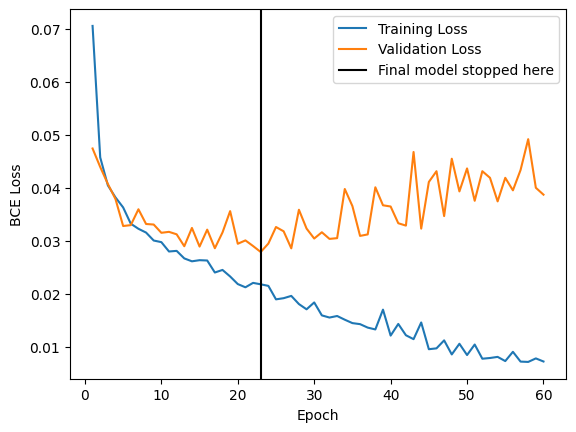

In [11]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
#plt.yscale('log')
plt.legend()

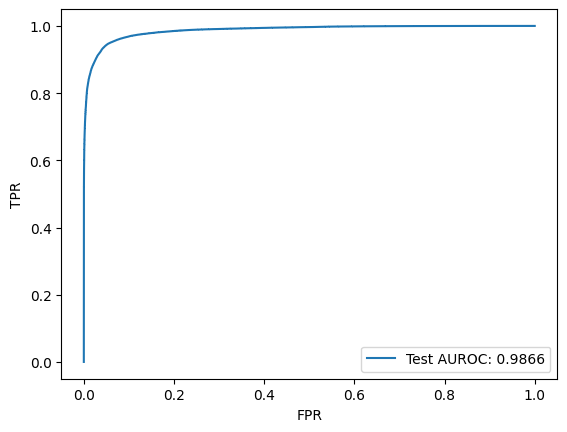

In [12]:
# Now test the pretrained model 
test_pred = mytools.test_clas(val_loader, final_classifier, device)

test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()

fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_val, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
#print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

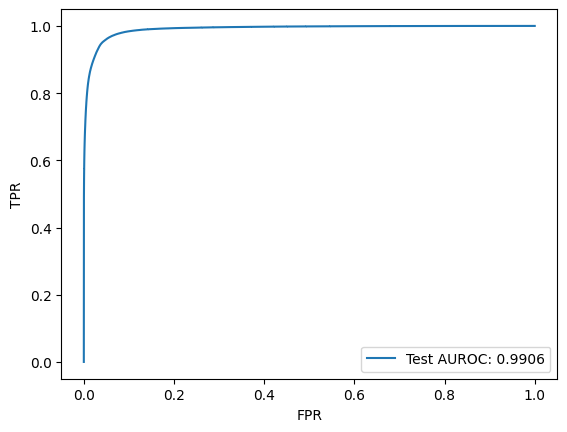

In [13]:
# Now test the pretrained model 
test_pred = mytools.test_clas(test_loader, final_classifier, device)

#bad_idx = np.where(~np.isfinite(test_pred))[0]
#print(bad_idx[:20])

#X_test_arr = np.asarray(X_test)
#print("X_test nan count:", np.isnan(X_test_arr).sum())
#print("X_test inf count:", np.isinf(X_test_arr).sum())

#print("bad rows in X_test:")
#print(X_test_arr[bad_idx[:10]])

#raw_pred = mytools.test_clas(test_loader, final_classifier, device)
#raw_pred_arr = np.asarray(raw_pred)

#print("raw_pred nan count:", np.isnan(raw_pred_arr).sum())
#print("raw_pred inf count:", np.isinf(raw_pred_arr).sum())
#print("first bad raw pred indices:", np.where(~np.isfinite(raw_pred_arr))[0][:20])

#test_pred = torch.sigmoid(torch.tensor(raw_pred)).numpy()
#print("sigmoid pred nan count:", np.isnan(test_pred).sum())
#print("first bad sigmoid indices:", np.where(~np.isfinite(test_pred))[0][:20])

test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


#print("y_test nan count:", np.isnan(np.asarray(y_test)).sum())
#print("test_pred nan count:", np.isnan(np.asarray(test_pred)).sum())

#print("y_test shape:", np.asarray(y_test).shape)
#print("test_pred shape:", np.asarray(test_pred).shape)

#print("test_pred min/max:", np.nanmin(test_pred), np.nanmax(test_pred))

fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
#print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

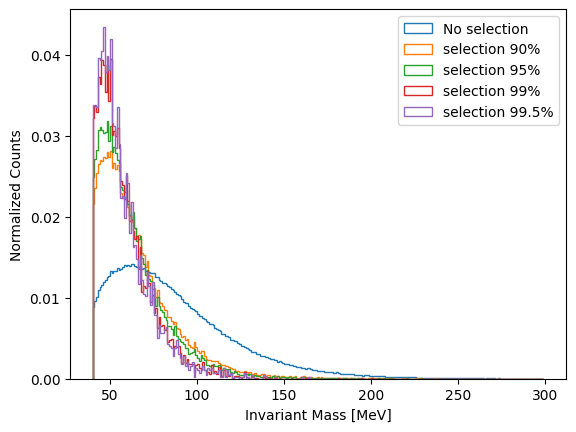

In [14]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.PhiKK == 0)]
per = np.percentile(df_bkg['Class_adv'],90)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
per = np.percentile(df_bkg['Class_adv'],95)
df_cut2 = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
per = np.percentile(df_bkg['Class_adv'],99)
df_cut3 = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
per = np.percentile(df_bkg['Class_adv'],99.5)
df_cut4 = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM
x_vals2 = 1000*df_cut2.InvM
x_vals3 = 1000*df_cut3.InvM
x_vals4 = 1000*df_cut4.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(40,300,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(40,300,1), histtype='step', label= 'selection 90%', density=True)
plt.hist(x_vals2, bins=np.arange(40,300,1), histtype='step', label= 'selection 95%', density=True)
plt.hist(x_vals3, bins=np.arange(40,300,1), histtype='step', label= 'selection 99%', density=True)
plt.hist(x_vals4, bins=np.arange(40,300,1), histtype='step', label= 'selection 99.5%', density=True)
#plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [15]:
# Save the pretrained classifier model
#torch.save(final_classifier.state_dict(), "/Users/mghrear/data/ML_data/patch/pretrained_classifier_2021_v9_pass5_run"+str(run)+"_limited.pt")


# Setup the adversary model

## Initialize model, objective function, and optimizer

In [16]:
adv = mytools.Adversary_small(n_classes=Num_classes).to(device)
criterion_adv = nn.CrossEntropyLoss(reduction='none')  # returns loss per sample so we can weight it (signal events are weighted as 0)
opt_adv = torch.optim.Adam(adv.parameters(), lr=1e-2)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(opt_adv, gamma=1.0)


## Setup dataloaders

In [17]:
# Convert to tensor dataset and dataloader

# the structure is: feature, adversary label, weight
# Weight is 0 for signal (PhiKK==1) so the adversary never trains on signal.
# For background rows: weight = sample_weight, upweighting MC events proportionally.

adv_w_train = ((y_train == 0).astype(float) * w_train).values.astype(np.float32)
adv_w_val   = ((y_val   == 0).astype(float) * w_val  ).values.astype(np.float32)

train_adv_dataset = TensorDataset(
    torch.from_numpy(X_train.to_numpy().astype(np.float32)),
    torch.from_numpy(y_adv_train),
    torch.from_numpy(adv_w_train))
train_adv_loader = DataLoader(train_adv_dataset, batch_size=bsize, shuffle=True)

val_adv_dataset = TensorDataset(
    torch.from_numpy(X_val.to_numpy().astype(np.float32)),
    torch.from_numpy(y_adv_val),
    torch.from_numpy(adv_w_val))
val_adv_loader = DataLoader(val_adv_dataset, batch_size=bsize, shuffle=True)

# Weights are not relevant for testing
test_adv_dataset = TensorDataset(
    torch.from_numpy(X_test.to_numpy().astype(np.float32)),
    torch.from_numpy(y_adv_test))
test_adv_loader = DataLoader(test_adv_dataset, batch_size=bsize, shuffle=True)


In [18]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored


Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 60
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_adv(train_adv_loader, final_classifier, adv, criterion_adv, opt_adv, scheduler_adv, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_adv(val_adv_loader, final_classifier, adv, criterion_adv, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_adv = copy.deepcopy(adv)

print("Done!")

Epoch 1
-------------------------------
Training loss: 2.208937
Validation loss: 2.196308 

Epoch 2
-------------------------------
Training loss: 2.166036
Validation loss: 2.192175 

Epoch 3
-------------------------------
Training loss: 2.160563
Validation loss: 2.164609 

Epoch 4
-------------------------------
Training loss: 2.158243
Validation loss: 2.160684 

Epoch 5
-------------------------------
Training loss: 2.155244
Validation loss: 2.162622 

Epoch 6
-------------------------------
Training loss: 2.154786
Validation loss: 2.156184 

Epoch 7
-------------------------------
Training loss: 2.154560
Validation loss: 2.157246 

Epoch 8
-------------------------------
Training loss: 2.152307
Validation loss: 2.158321 

Epoch 9
-------------------------------
Training loss: 2.152895
Validation loss: 2.154768 

Epoch 10
-------------------------------
Training loss: 2.152749
Validation loss: 2.154998 

Epoch 11
-------------------------------
Training loss: 2.152374
Validation los

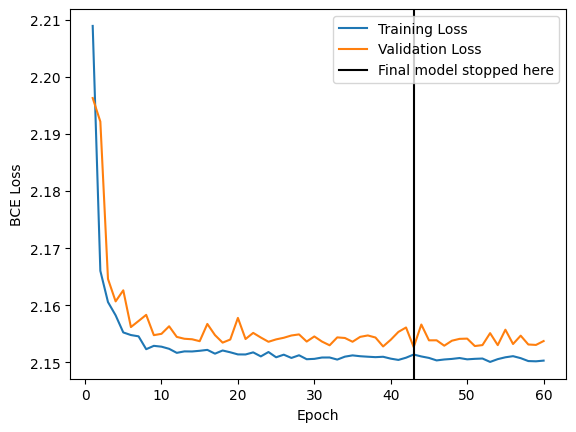

In [19]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()

# Train full adverserial neural network

# Setup dataloaders

In [20]:
# the structure is: feature, classifier label, adversary label, weight, clas_mask
# weight: 0 for signal (masks adv loss), sample_weight for background.
# clas_mask: 1 within ±8 MeV of MASS, 0 outside — applied to classifier BCE loss only.
# The adversary sees ALL events regardless of clas_mask.

train_full_dataset = TensorDataset(
    torch.from_numpy(X_train.to_numpy().astype(np.float32)),
    torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1),
    torch.from_numpy(y_adv_train),
    torch.from_numpy(adv_w_train),
    torch.from_numpy(clas_mask_train).unsqueeze(1))
train_full_loader = DataLoader(train_full_dataset, batch_size=bsize, shuffle=True)

val_full_dataset = TensorDataset(
    torch.from_numpy(X_val.to_numpy().astype(np.float32)),
    torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1),
    torch.from_numpy(y_adv_val),
    torch.from_numpy(adv_w_val),
    torch.from_numpy(clas_mask_val).unsqueeze(1))
val_full_loader = DataLoader(val_full_dataset, batch_size=bsize, shuffle=True)


## Define loss functions

In [21]:
BCE_loss_unreduced = nn.BCEWithLogitsLoss(reduction='none')
CE_loss  = nn.CrossEntropyLoss(reduction='none')

def full_loss(output_clas, output_adv, target_clas, target_adv, w, lambda_, clas_mask):
    """
    w        : per-sample weight — 0 for signal, sample_weight for background.
    clas_mask: 1 within ±8 MeV of MASS, 0 outside. Applied to classifier BCE only.
               The adversary loss uses ALL background events regardless of clas_mask.

    Classifier loss: weighted mean over events inside the mass window.
      Signal rows (w==0) get weight 1; background rows get sample_weight.
      Both are then multiplied by clas_mask, so only in-window events contribute.
    Adversary loss: weighted mean over ALL background rows (w > 0), full mass range.
    """
    # ── Classifier loss (mass-windowed) ──
    clas_w = torch.where(w > 0, w, torch.ones_like(w)) * clas_mask
    sample_losses1 = BCE_loss_unreduced(output_clas, target_clas)
    loss1 = (sample_losses1 * clas_w).sum() / clas_w.sum().clamp(min=1)

    # ── Adversary loss (full mass range, background only) ──
    sample_losses2 = CE_loss(output_adv, target_adv)
    nonzero = w > 0
    loss2 = (sample_losses2[nonzero] * w[nonzero]).sum() / w[nonzero].sum()

    loss = loss1 - lambda_ * loss2
    return loss


## Setup optimizers

In [22]:
optimizer_clas = optim.Adam(final_classifier.parameters(), lr=1e-2,betas=(0.9, 0.999))
optimizer_adv = optim.Adam(final_adv.parameters(), lr=1e-2,betas=(0.9, 0.999))

scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=0.999)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(optimizer_adv, gamma=0.999)

## Adversarial training

In [23]:
Training_losses_clas = np.array([])
Training_losses_adv = np.array([])
Validation_losses_clas = np.array([])
Validation_losses_adv = np.array([])
diff_scores = np.array([])

N_ADV_STEPS = 8  # adversary updates per classifier update

def train_full_windowed(loader, classifier, adv, loss_fn, lambda_,
                         crit_adv, opt_clas, opt_adv, sched_clas, sched_adv, device):
    classifier.train(); adv.train()
    total_clas, total_adv = 0.0, 0.0
    for X, y_c, y_a, w, cmask in loader:
        X, y_c, y_a, w, cmask = X.to(device), y_c.to(device), y_a.to(device), w.to(device), cmask.to(device)
        # ── Adversary steps ──
        for _ in range(N_ADV_STEPS):
            opt_adv.zero_grad()
            with torch.no_grad(): out_c = classifier(X)
            out_a = adv(out_c)
            nonzero = w.squeeze() > 0
            if nonzero.sum() > 0:
                adv_losses = crit_adv(out_a[nonzero], y_a[nonzero])
                adv_loss = (adv_losses * w.squeeze()[nonzero]).sum() / w.squeeze()[nonzero].sum()
                adv_loss.backward()
                opt_adv.step()
        # ── Classifier step ──
        opt_clas.zero_grad()
        out_c = classifier(X)
        out_a = adv(out_c)
        loss = loss_fn(out_c, out_a, y_c, y_a, w.squeeze(), lambda_, cmask)
        loss.backward()
        opt_clas.step()
        total_clas += loss.item()
        with torch.no_grad():
            nonzero = w.squeeze() > 0
            if nonzero.sum() > 0:
                al = crit_adv(out_a[nonzero], y_a[nonzero])
                total_adv += ((al * w.squeeze()[nonzero]).sum() / w.squeeze()[nonzero].sum()).item()
    sched_clas.step(); sched_adv.step()
    return total_clas / len(loader), total_adv / len(loader)

def validate_full_windowed(loader, classifier, adv, loss_fn, lambda_, crit_adv, device):
    classifier.eval(); adv.eval()
    total_clas, total_adv = 0.0, 0.0
    with torch.no_grad():
        for X, y_c, y_a, w, cmask in loader:
            X, y_c, y_a, w, cmask = X.to(device), y_c.to(device), y_a.to(device), w.to(device), cmask.to(device)
            out_c = classifier(X)
            out_a = adv(out_c)
            loss = loss_fn(out_c, out_a, y_c, y_a, w.squeeze(), lambda_, cmask)
            total_clas += loss.item()
            nonzero = w.squeeze() > 0
            if nonzero.sum() > 0:
                al = crit_adv(out_a[nonzero], y_a[nonzero])
                total_adv += ((al * w.squeeze()[nonzero]).sum() / w.squeeze()[nonzero].sum()).item()
    return total_clas / len(loader), total_adv / len(loader)

epochs = 19
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")

    E_clas_training_loss, E_adv_training_loss = train_full_windowed(
        train_full_loader, final_classifier, final_adv, full_loss, lambda_,
        criterion_adv, optimizer_clas, optimizer_adv, scheduler_clas, scheduler_adv, device)
    Training_losses_clas = np.append(Training_losses_clas, E_clas_training_loss)
    Training_losses_adv  = np.append(Training_losses_adv,  E_adv_training_loss)

    E_clas_val_loss, E_adv_val_loss = validate_full_windowed(
        val_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, device)
    Validation_losses_clas = np.append(Validation_losses_clas, E_clas_val_loss)
    Validation_losses_adv  = np.append(Validation_losses_adv,  E_adv_val_loss)

    # Get the diff_score (measure of how much the invariant mass distribution changes after selection)
    df_test["Class_adv"] = mytools.test_clas(test_loader, final_classifier, device)
    df_bkg = df_test.loc[ (df_test.PhiKK == 0) ]
    per = np.percentile(df_bkg['Class_adv'],90)
    df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
    x1 = 1000*df_bkg.InvM.values
    x2 = 1000*df_cut.InvM.values
    diff_scores = np.append(diff_scores, mytools.get_diff_score(x1,x2))

    print(f"Diff score: {diff_scores[-1]:>7f}")

    # Keep a running copy of the model with the lowest diff_score
    if diff_scores[-1] == np.min(diff_scores):
        final_clas_adv = copy.deepcopy(final_classifier)
        final_adv_adv  = copy.deepcopy(final_adv)

print("Done!")


Epoch 1
-------------------------------
Diff score: 2.960755
Epoch 2
-------------------------------
Diff score: 4.514787
Epoch 3
-------------------------------
Diff score: 5.691445
Epoch 4
-------------------------------
Diff score: 8.223486
Epoch 5
-------------------------------
Diff score: 4.207736
Epoch 6
-------------------------------
Diff score: 5.331173
Epoch 7
-------------------------------
Diff score: 9.049319
Epoch 8
-------------------------------
Diff score: 2.873021
Epoch 9
-------------------------------
Diff score: 1.803429
Epoch 10
-------------------------------
Diff score: 2.421798
Epoch 11
-------------------------------
Diff score: 3.333674
Epoch 12
-------------------------------
Diff score: 3.115693
Epoch 13
-------------------------------
Diff score: 2.160503
Epoch 14
-------------------------------
Diff score: 2.422331
Epoch 15
-------------------------------
Diff score: 1.391144
Epoch 16
-------------------------------
Diff score: 3.117608
Epoch 17
--------

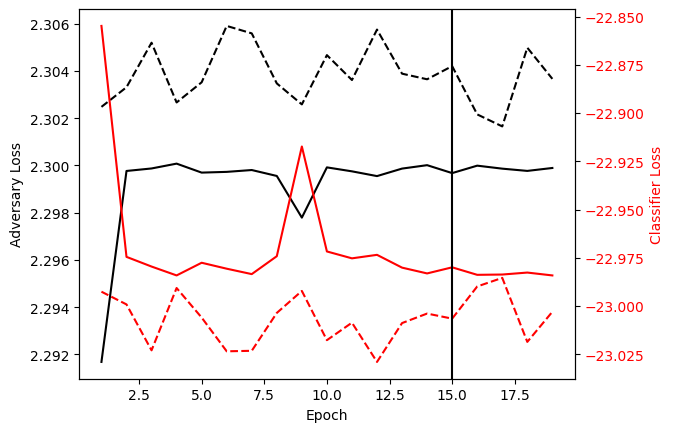

In [24]:
# Plot the training and Validation Losses

fig, ax1 = plt.subplots()

best_epoch = np.argmin(diff_scores)+1



ax1.plot(np.arange(len(Training_losses_adv))+1, Training_losses_adv, 'k-', label='Training Adversary')
ax1.plot(np.arange(len(Validation_losses_adv))+1, Validation_losses_adv, 'k--', label='Validation Adversary')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Adversary Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

ax2 = ax1.twinx()

ax2.plot(np.arange(len(Training_losses_clas))+1, Training_losses_clas, 'r-', label='Training Classifier')
ax2.plot(np.arange(len(Validation_losses_clas))+1, Validation_losses_clas, 'r--', label='Validation Classifier')
ax2.axvline(best_epoch,label="Final model stopped here",color='k')

ax2.set_ylabel('Classifier Loss', color='r')
ax2.tick_params(axis='y', labelcolor='r')



Text(0.5, 0, 'Epoch')

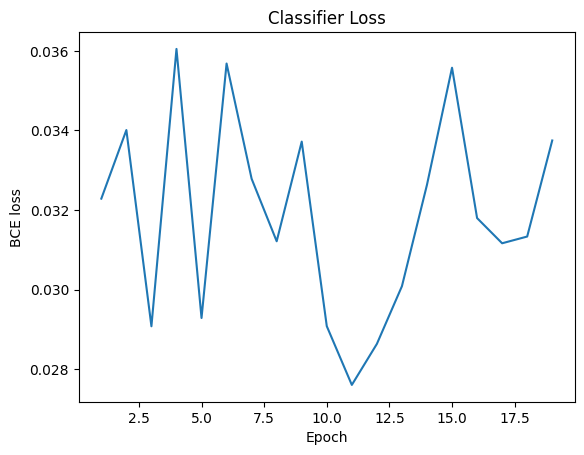

In [25]:
# This shows the BCE loss of the classifier
Validation_losses_clas+lambda_*Validation_losses_adv

plt.title("Classifier Loss")
plt.plot(np.arange(len(Training_losses_adv))+1, Validation_losses_clas+lambda_*Validation_losses_adv)
plt.ylabel("BCE loss")
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

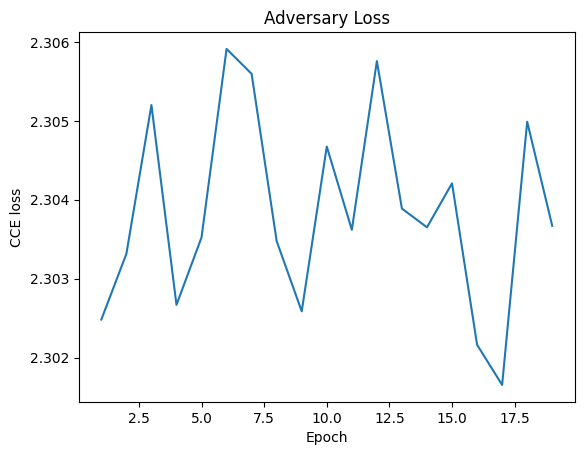

In [26]:
# This shows the CCE loss of the Adversary
plt.title("Adversary Loss")
plt.plot(np.arange(len(Training_losses_adv))+1, Validation_losses_adv)
plt.ylabel("CCE loss")
plt.xlabel('Epoch')

## Test adversarially trained models

Test AUROC: 0.9960


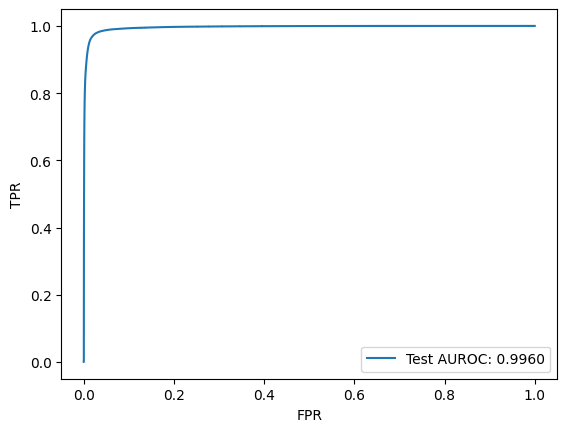

In [27]:
# Now test the model selected using diff_score
test_pred = mytools.test_clas(test_loader, final_clas_adv, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

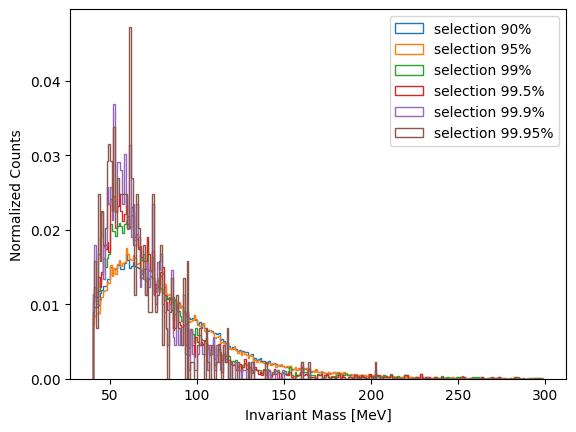

In [28]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.PhiKK == 0)]
per = np.percentile(df_bkg['Class_adv'],90.0)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM
per = np.percentile(df_bkg['Class_adv'],95.0)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals2 = 1000*df_cut.InvM
per = np.percentile(df_bkg['Class_adv'],99.0)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals3 = 1000*df_cut.InvM
per = np.percentile(df_bkg['Class_adv'],99.5)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals4 = 1000*df_cut.InvM
per = np.percentile(df_bkg['Class_adv'],99.9)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals5 = 1000*df_cut.InvM
per = np.percentile(df_bkg['Class_adv'],99.95)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals6 = 1000*df_cut.InvM
per = np.percentile(df_bkg['Class_adv'],99.99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals7 = 1000*df_cut.InvM

plt.figure()
#plt.hist(1000*df_bkg.InvM, bins=np.arange(40,300,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(40,300,1), histtype='step', label= 'selection 90%', density=True)
plt.hist(x_vals2, bins=np.arange(40,300,1), histtype='step', label= 'selection 95%', density=True)
plt.hist(x_vals3, bins=np.arange(40,300,1), histtype='step', label= 'selection 99%', density=True)
plt.hist(x_vals4, bins=np.arange(40,300,1), histtype='step', label= 'selection 99.5%', density=True)
plt.hist(x_vals5, bins=np.arange(40,300,1), histtype='step', label= 'selection 99.9%', density=True)
plt.hist(x_vals6, bins=np.arange(40,300,1), histtype='step', label= 'selection 99.95%', density=True)
#plt.hist(x_vals7, bins=np.arange(40,300,1), histtype='step', label= 'selection 99.99%', density=True)
#plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

Test AUROC: 0.9941


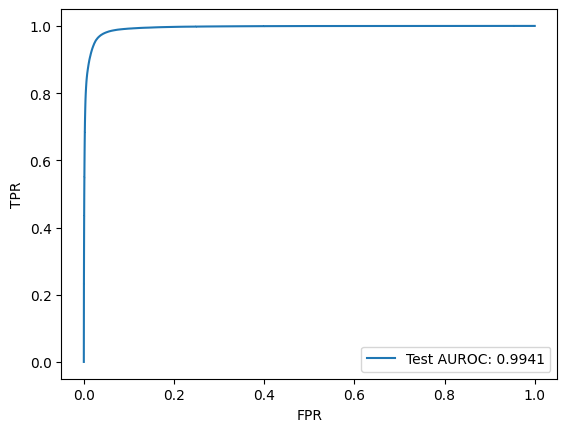

In [29]:
# Now test the model without early stopping criteria
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

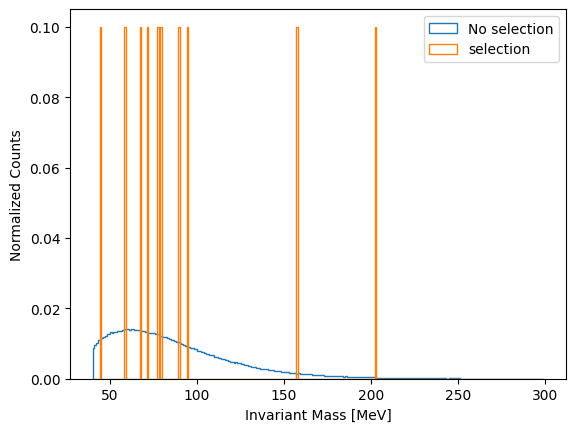

In [30]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.PhiKK == 0)]
per = np.percentile(df_bkg['Class_adv'],99.999)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(40,300,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(40,300,1), histtype='step', label= 'selection', density=True)
#plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

class 0 test auc score: 0.5
class 1 test auc score: 0.5
class 2 test auc score: 0.5
class 3 test auc score: 0.5
class 4 test auc score: 0.5
class 5 test auc score: 0.5
class 6 test auc score: 0.5
class 7 test auc score: 0.5
class 8 test auc score: 0.5
class 9 test auc score: 0.5
average score:  0.5


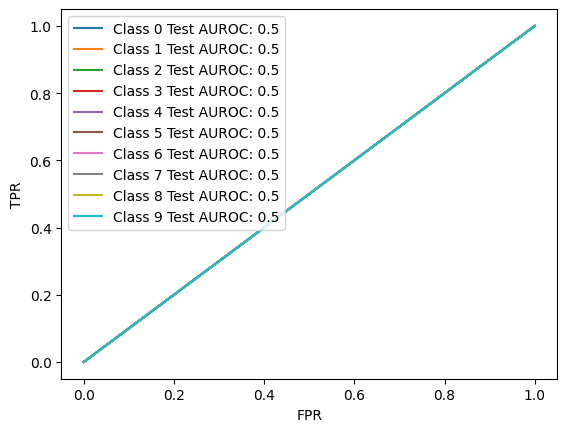

In [31]:

adv_test_pred = mytools.test_adv(test_adv_loader, final_classifier, final_adv, Num_classes, device)
adv_test_pred = torch.softmax(torch.tensor(adv_test_pred),dim=1).numpy()
score=0

for i in range(adv_test_pred.shape[1]):
    fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_adv_test[:,i], adv_test_pred[:,i], pos_label=1)
    auc_test = sklearn.metrics.auc(fpr, tpr)
    print("class " + str(i)+ " test auc score: " + str(auc_test))

    plt.plot(fpr, tpr, label='Class '+str(i)+' Test AUROC: '+str(auc_test))
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend()

    score += auc_test

print("average score: ", score/adv_test_pred.shape[1])

In [ ]:
# Save the adversarially trained models
torch.save(final_clas_adv.state_dict(), "classifier_adv_2021_v9_pass5_run"+str(run)+"QualCuts_"+str(MASS)+"_v3.pt")
torch.save(final_adv_adv.state_dict(), "adversary_adv_2021_v9_pass5_run"+str(run)+"QualCuts_"+str(MASS)+"_v3.pt")

# Data vs. data-like MC diagnostic

Score histograms and ROC curve showing how well the final classifier
separates real data from data-like MC. Ideally these should be similar.

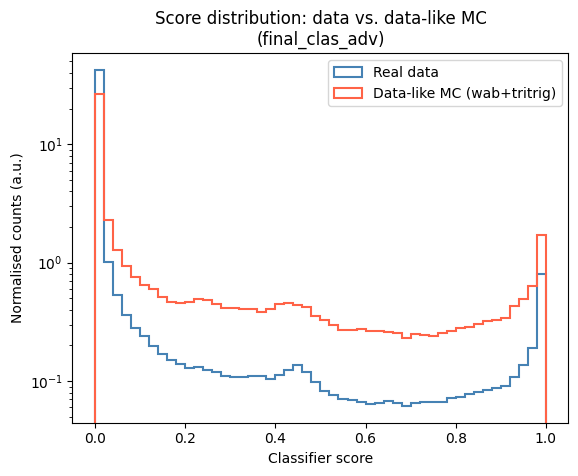

Data-vs-MC AUROC (ideally ~0.5): 0.7487


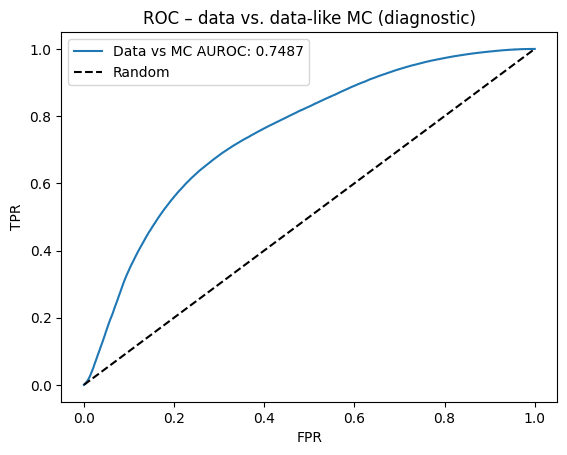

In [33]:
# Build a test set of real data background vs. data-like MC background
# to check whether the classifier has learned MC/data artefacts.
df_mc_bkg_test_diag = df_mc_bkg_test.copy()
df_data_bkg_test_diag = df_bigpreselectblind_test.copy()
df_mc_bkg_test_diag  ['MC_label'] = 1.0
df_data_bkg_test_diag['MC_label'] = 0.0

df_dm_diag = pd.concat([df_data_bkg_test_diag, df_mc_bkg_test_diag],
                        ignore_index=True, sort=False)
X_dm_diag = df_dm_diag.drop(columns=['InvM','PhiKK','MC_label'])
y_dm_diag = df_dm_diag['MC_label'].to_numpy()
X_dm_diag = pd.DataFrame(scaler.transform(X_dm_diag),
                          columns=X_dm_diag.columns, index=X_dm_diag.index)

dm_diag_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_dm_diag.to_numpy().astype(np.float32))),
    batch_size=bsize, shuffle=False)

scores_diag = mytools.test_clas(dm_diag_loader, final_clas_adv, device)
scores_diag = torch.sigmoid(torch.tensor(scores_diag)).numpy()

scores_data_diag = scores_diag[y_dm_diag == 0]
scores_mc_diag   = scores_diag[y_dm_diag == 1]

# Unit-normalised score histograms
bins = np.linspace(0, 1, 51)
plt.figure()
plt.hist(scores_data_diag, bins=bins, histtype='step', density=True,
         label='Real data', color='steelblue', linewidth=1.5)
plt.hist(scores_mc_diag,   bins=bins, histtype='step', density=True,
         label='Data-like MC (wab+tritrig)', color='tomato', linewidth=1.5)
plt.xlabel('Classifier score')
plt.ylabel('Normalised counts (a.u.)')
plt.yscale('log')
plt.title('Score distribution: data vs. data-like MC\n(final_clas_adv)')
plt.legend()
plt.show()

# ROC curve for data vs. MC (diagnostic — should be close to random)
fpr_dm, tpr_dm, _ = sklearn.metrics.roc_curve(y_dm_diag, scores_diag, pos_label=1)
auc_dm = sklearn.metrics.auc(fpr_dm, tpr_dm)
print(f'Data-vs-MC AUROC (ideally ~0.5): {auc_dm:.4f}')
plt.figure()
plt.plot(fpr_dm, tpr_dm, label=f'Data vs MC AUROC: {auc_dm:.4f}')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC – data vs. data-like MC (diagnostic)')
plt.legend()
plt.show()


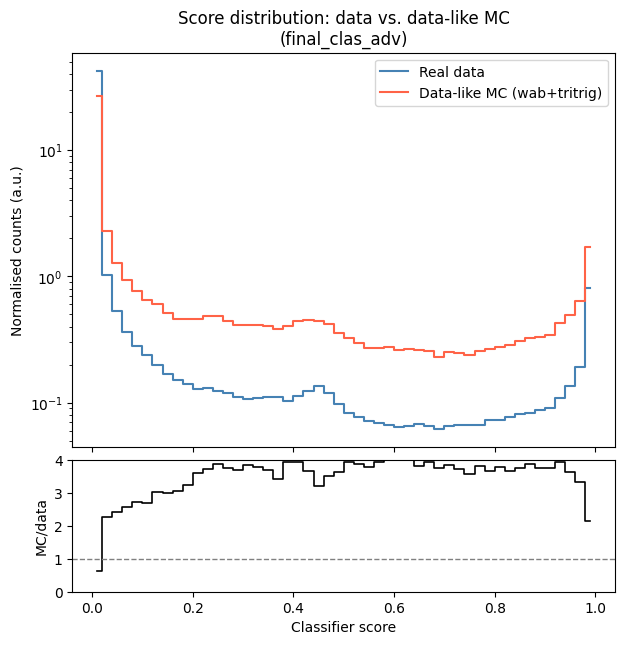

Data-vs-MC AUROC (ideally ~0.5): 0.7487


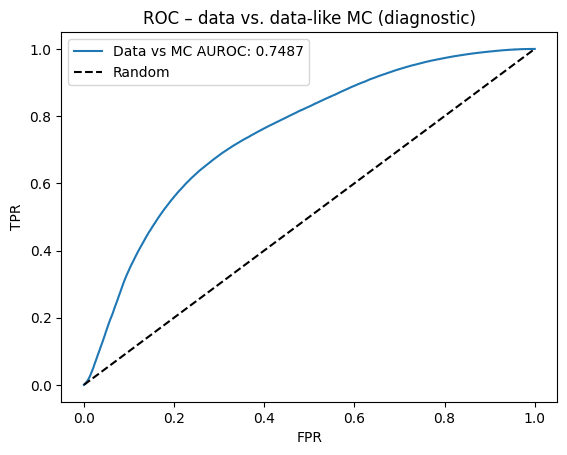

In [34]:
# Build a test set of real data background vs. data-like MC background
# to check whether the classifier has learned MC/data artefacts.
df_mc_bkg_test_diag = df_mc_bkg_test.copy()
df_data_bkg_test_diag = df_bigpreselectblind_test.copy()
df_mc_bkg_test_diag  ['MC_label'] = 1.0
df_data_bkg_test_diag['MC_label'] = 0.0

df_dm_diag = pd.concat([df_data_bkg_test_diag, df_mc_bkg_test_diag],
                        ignore_index=True, sort=False)
X_dm_diag = df_dm_diag.drop(columns=['InvM','PhiKK','MC_label'])
y_dm_diag = df_dm_diag['MC_label'].to_numpy()
X_dm_diag = pd.DataFrame(scaler.transform(X_dm_diag),
                          columns=X_dm_diag.columns, index=X_dm_diag.index)

dm_diag_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_dm_diag.to_numpy().astype(np.float32))),
    batch_size=bsize, shuffle=False)

scores_diag = mytools.test_clas(dm_diag_loader, final_clas_adv, device)
scores_diag = torch.sigmoid(torch.tensor(scores_diag)).numpy()

scores_data_diag = scores_diag[y_dm_diag == 0]
scores_mc_diag   = scores_diag[y_dm_diag == 1]

# Unit-normalised score histograms + MC/data ratio
bins = np.linspace(0, 1, 51)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_widths = np.diff(bins)

data_counts, _ = np.histogram(scores_data_diag, bins=bins)
mc_counts, _   = np.histogram(scores_mc_diag,   bins=bins)

data_total = np.sum(data_counts)
mc_total   = np.sum(mc_counts)

data_density = data_counts / (data_total * bin_widths)
mc_density   = mc_counts   / (mc_total   * bin_widths)

ratio = np.divide(mc_density, data_density,
                  out=np.full_like(mc_density, np.nan, dtype=float),
                  where=data_density > 0)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7, 7), sharex=True,
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
)

ax1.step(bin_centers, data_density, where='mid',
         label='Real data', color='steelblue', linewidth=1.5)
ax1.step(bin_centers, mc_density, where='mid',
         label='Data-like MC (wab+tritrig)', color='tomato', linewidth=1.5)
ax1.set_ylabel('Normalised counts (a.u.)')
ax1.set_yscale('log')
ax1.set_title('Score distribution: data vs. data-like MC\n(final_clas_adv)')
ax1.legend()

ax2.step(bin_centers, ratio, where='mid', color='black', linewidth=1.2)
ax2.axhline(1.0, linestyle='--', color='gray', linewidth=1.0)
ax2.set_xlabel('Classifier score')
ax2.set_ylabel('MC/data')
ax2.set_ylim(0.0, 4.0)

plt.show()

# ROC curve for data vs. MC (diagnostic — should be close to random)
fpr_dm, tpr_dm, _ = sklearn.metrics.roc_curve(y_dm_diag, scores_diag, pos_label=1)
auc_dm = sklearn.metrics.auc(fpr_dm, tpr_dm)
print(f'Data-vs-MC AUROC (ideally ~0.5): {auc_dm:.4f}')

plt.figure()
plt.plot(fpr_dm, tpr_dm, label=f'Data vs MC AUROC: {auc_dm:.4f}')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC – data vs. data-like MC (diagnostic)')
plt.legend()
plt.show()